# Assignment 13: Decision Tree Classification on Heart Disease Dataset
##### Author: Md Ashhar Farooqui
##### Date: 20-07-2025

This notebook implements a Decision Tree Classifier on the heart disease dataset. It includes data loading, exploratory data analysis (EDA), feature engineering, model training, evaluation, hyperparameter tuning, and visualization.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [24]:
# Load the dataset
df = pd.read_excel('heart_disease.xlsx', sheet_name='Heart_disease')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [25]:
# Basic info and missing values check
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB

Missing values per column:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [28]:
df.duplicated().sum()

np.int64(1)

In [29]:
df.drop_duplicates(inplace=True)

In [30]:
df.duplicated().sum()

np.int64(0)

In [33]:
# Statistical summary
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,907.000000,907.000000,907.000000,907.000000,845.000000,907.000000
mean,53.787211,133.412348,201.465270,135.976847,0.892308,1.007718
std,9.162016,20.405432,112.158285,26.813075,1.094092,1.144594
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.500000,120.000000,176.500000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


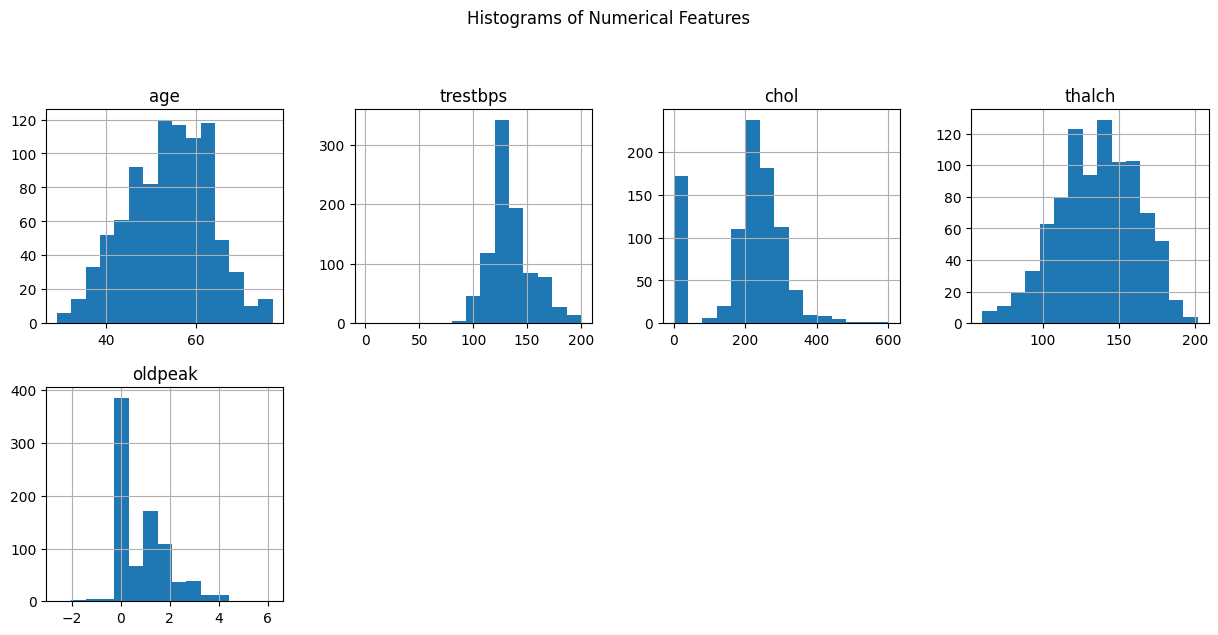

In [32]:
# Visualize distributions of numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('num')  # target variable
df[num_cols].hist(bins=15, figsize=(15, 10), layout=(3, 4))
plt.suptitle('Histograms of Numerical Features')
plt.show()

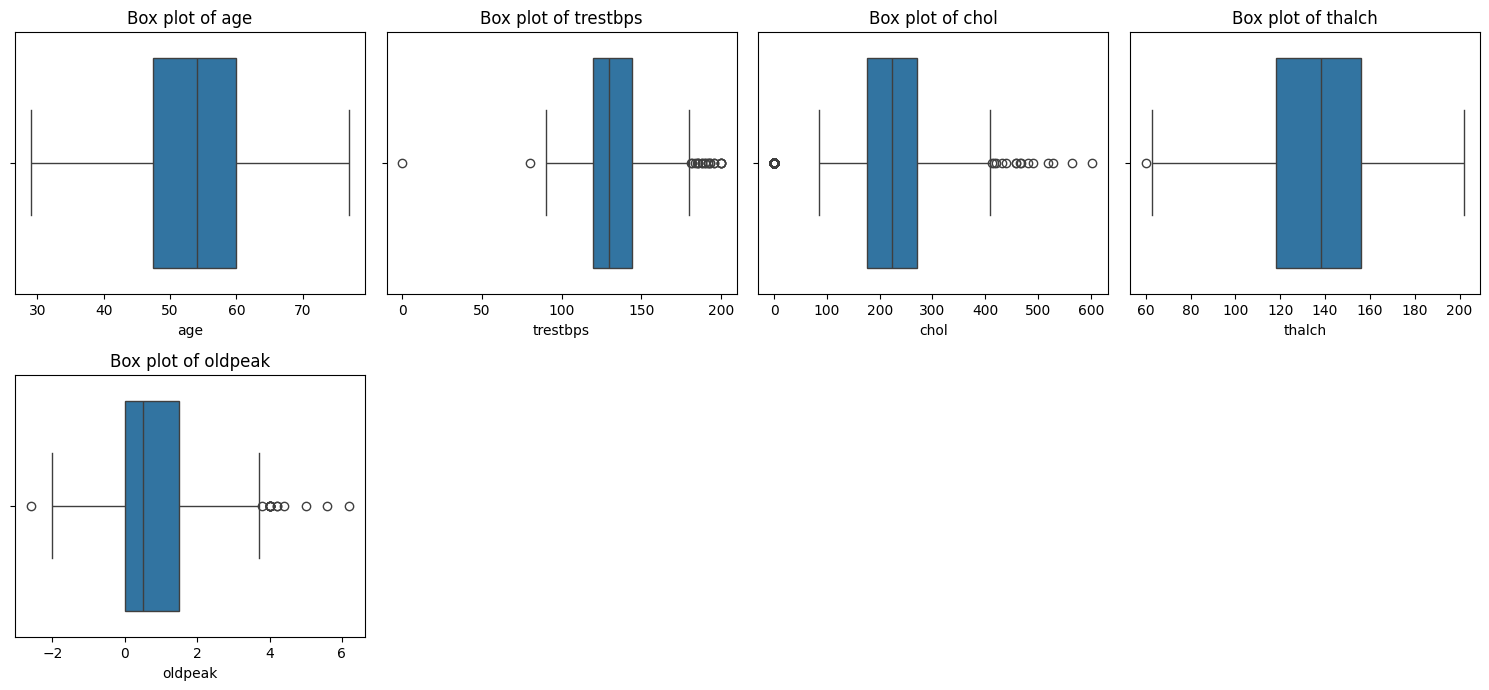

In [34]:
# Box plots to check for outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [37]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (object and bool types)
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print('Categorical columns:', cat_cols)

# Convert bool to string to make LabelEncoder happy
df[cat_cols] = df[cat_cols].astype(str)

# Apply LabelEncoder to each categorical column
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


Categorical columns: ['fbs', 'exang', 'slope', 'thal']


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0


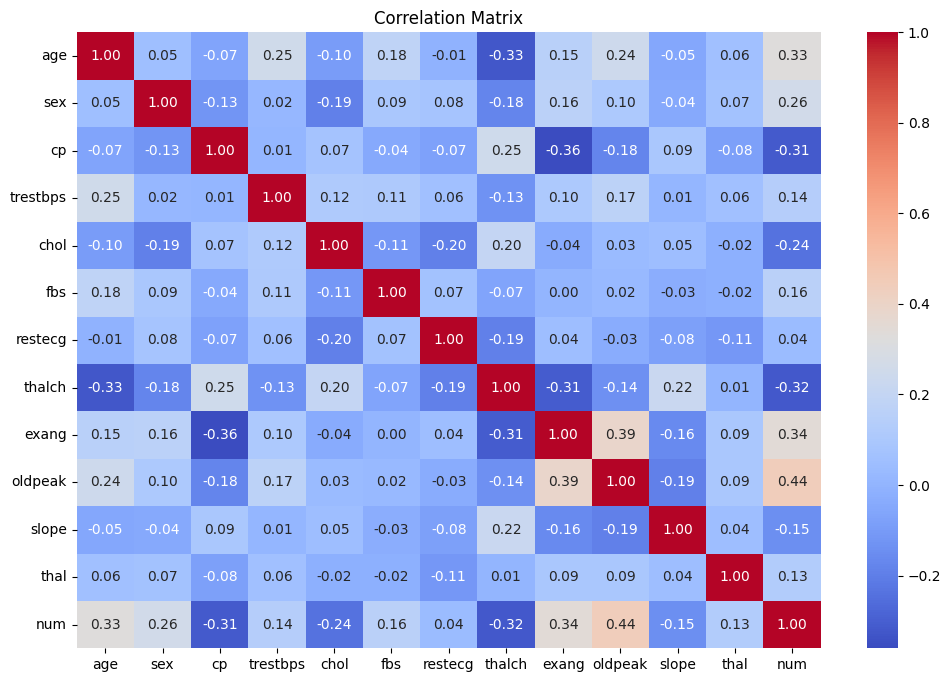

In [38]:
# Correlation matrix heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [39]:
# Encode categorical variables properly to avoid conversion errors
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', cat_cols)

# Use pandas get_dummies for one-hot encoding to handle categorical variables robustly
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()

Categorical columns: []


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0


In [40]:
# Define features and target
X = df.drop('num', axis=1)
y = df['num']

# Split data into train and test sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}')

Training samples: 725, Testing samples: 182


In [41]:
# Train Decision Tree Classifier with default parameters
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
# Predict on test set
y_pred = dtc.predict(X_test)
y_proba = dtc.predict_proba(X_test)

In [43]:
# Evaluate model
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('ROC AUC:', roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted'))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.5384615384615384
Precision: 0.5368379849254166
Recall: 0.5384615384615384
F1 Score: 0.5346338535414165
ROC AUC: 0.6774226508983175

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73        89
           1       0.44      0.57      0.50        47
           2       0.25      0.25      0.25        20
           3       0.22      0.24      0.23        17
           4       0.00      0.00      0.00         9

    accuracy                           0.54       182
   macro avg       0.34      0.35      0.34       182
weighted avg       0.54      0.54      0.53       182



In [44]:
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation accuracy:', grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best cross-validation accuracy: 0.5448275862068965


In [45]:
# Retrain model with best parameters
best_dtc = grid_search.best_estimator_
best_dtc.fit(X_train, y_train)

# Predict and evaluate again
y_pred_best = best_dtc.predict(X_test)
y_proba_best = best_dtc.predict_proba(X_test)

print('Accuracy (best model):', accuracy_score(y_test, y_pred_best))
print('Precision (best model):', precision_score(y_test, y_pred_best, average='weighted'))
print('Recall (best model):', recall_score(y_test, y_pred_best, average='weighted'))
print('F1 Score (best model):', f1_score(y_test, y_pred_best, average='weighted'))
print('ROC AUC (best model):', roc_auc_score(y_test, y_proba_best, multi_class='ovr', average='weighted'))

Accuracy (best model): 0.5769230769230769
Precision (best model): 0.46934235449130307
Recall (best model): 0.5769230769230769
F1 Score (best model): 0.5165259450973737
ROC AUC (best model): 0.7877317611406118


c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


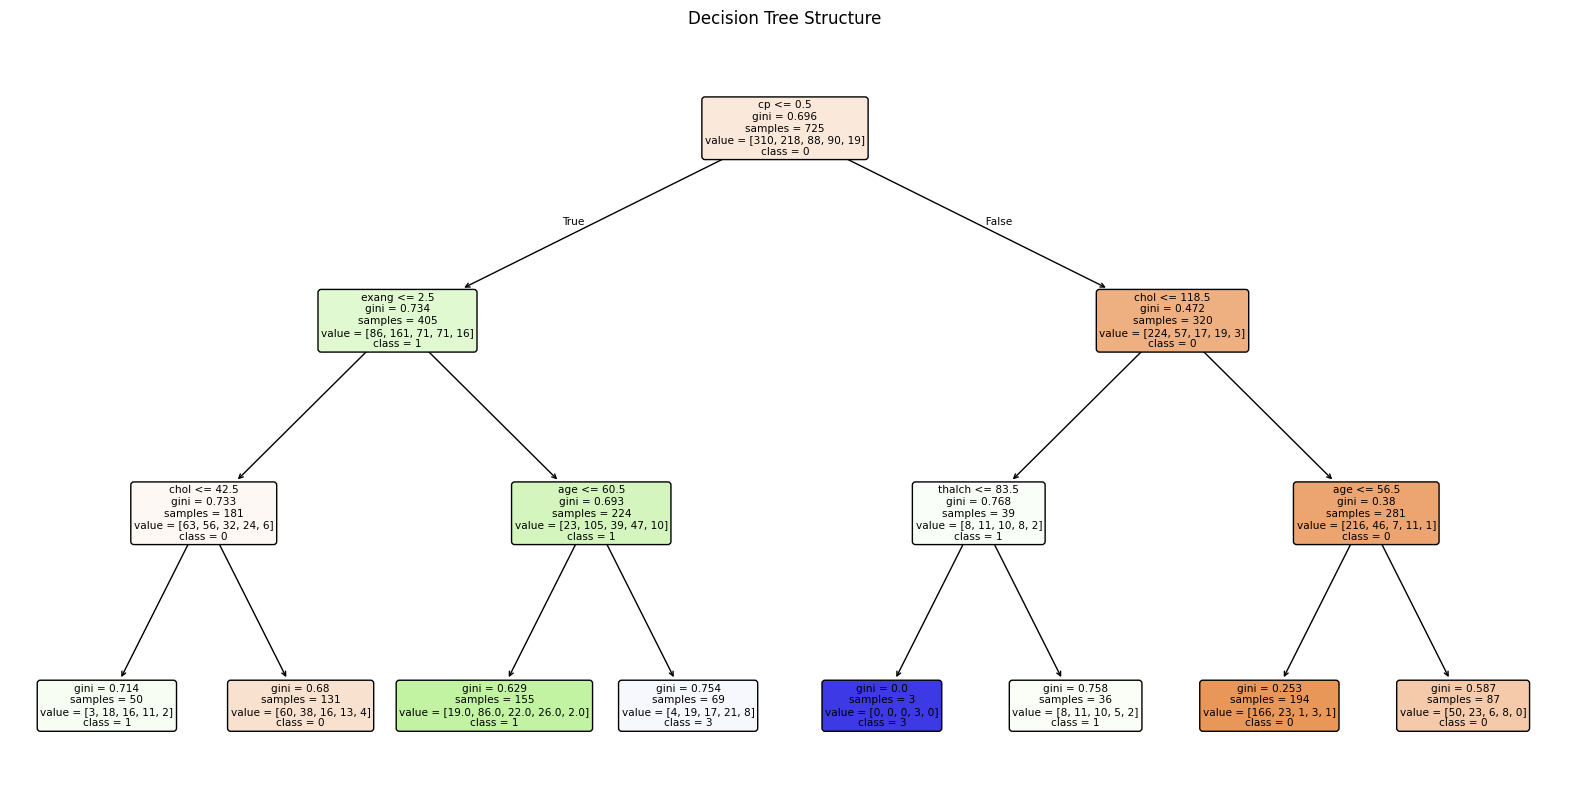

In [46]:
# Visualize decision tree
plt.figure(figsize=(20, 10))
plot_tree(best_dtc, feature_names=X.columns, class_names=[str(c) for c in best_dtc.classes_], filled=True, rounded=True)
plt.title('Decision Tree Structure')
plt.show()

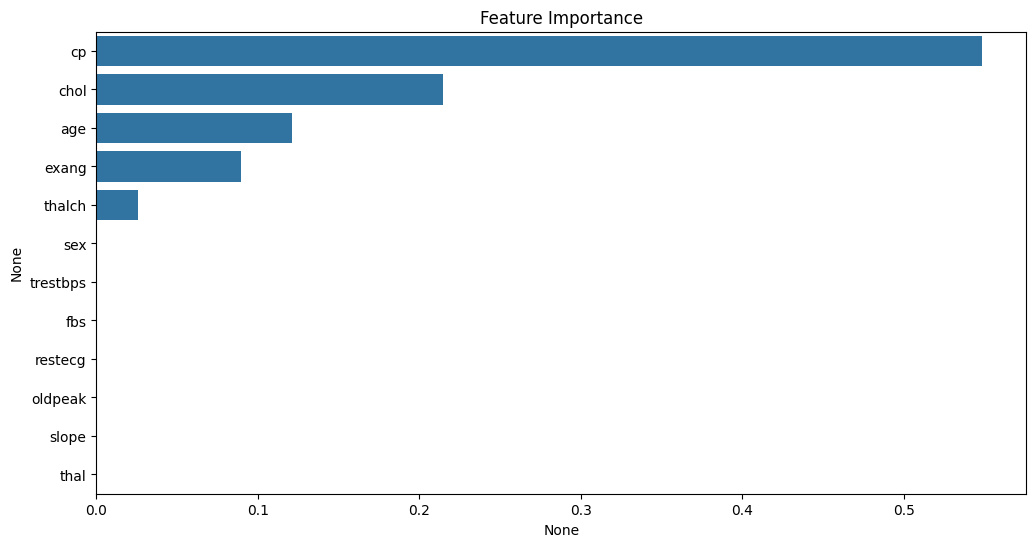

In [47]:
# Feature importance
feat_importances = pd.Series(best_dtc.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title('Feature Importance')
plt.show()

## Summary

- The Decision Tree Classifier was trained on the heart disease dataset.
- Initial evaluation showed the model's performance on accuracy, precision, recall, F1-score, and ROC AUC.
- Hyperparameter tuning improved the model performance.
- The decision tree structure and feature importance were visualized to interpret the model.

This completes the Decision Tree Classification task.